# Day 1 Signal Validation: EDI v2

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime, timedelta
import warnings
from dotenv import load_dotenv

warnings.filterwarnings('ignore')
load_dotenv('../.env')
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))

from src.data.binance_client import BinanceClient
from src.data.fng_client import FNGClient
from src.data.funding_client import FundingClient
from src.data.lunarcrush_client import LunarCrushClient
from src.signals.edi import compute_edi_v2

In [2]:
# Initialize clients
binance = BinanceClient()
fng = FNGClient(cache_dir=os.path.abspath(os.path.join(os.getcwd(), '..', 'data')))
funding = FundingClient()
lunarcrush = LunarCrushClient()

assets = ["BTCUSDT", "ETHUSDT", "BNBUSDT"]
days = 365

# Fetch F&G (it's market-wide)
print("Fetching Market F&G Data...")
df_fng = fng.get_historical_fng(days=days)
df_fng_daily = df_fng.resample('1D').last()


Fetching Market F&G Data...


In [3]:
def process_asset(symbol):
    print(f"\nProcessing {symbol}...")
    df_price = binance.get_historical_ohlcv(symbol, days=days, interval="1d")
    df_funding = funding.get_funding_history(symbol, days=days)
    df_social = lunarcrush.get_historical_social(symbol.replace('USDT', ''), days=days)
    
    df_price_daily = df_price.resample('1D').last()
    df_funding_daily = df_funding.resample('1D').last()
    if not df_social.empty:
        df_social_daily = df_social.resample('1D').last()
    else:
        df_social_daily = pd.DataFrame(index=df_price_daily.index)

    df = pd.DataFrame(index=df_price_daily.index)
    df['close'] = df_price_daily['close']
    df['fng_value'] = df_fng_daily['value']
    df['fundingRate'] = df_funding_daily['fundingRate']
    df['social_sentiment'] = df_social_daily['sentiment'] if 'sentiment' in df_social_daily.columns else 50.0

    df = df.dropna(subset=['close', 'fng_value', 'fundingRate'])
    df['social_sentiment'] = df['social_sentiment'].fillna(50.0)
    
    # Compute 7d forward and 14d forward returns
    df['future_7d_return'] = df['close'].shift(-7) / df['close'] - 1
    df['future_14d_return'] = df['close'].shift(-14) / df['close'] - 1
    
    # Compute EDI v2
    edi_scores = []
    edi_directions = []
    
    for i in range(len(df)):
        if i < 14:  # Need at least 14 days of history
            edi_scores.append(0)
            edi_directions.append("no_signal")
            continue
            
        fng_hist = df['fng_value'].iloc[max(0, i-14):i+1]
        funding_hist = df['fundingRate'].iloc[max(0, i-7):i+1]
        price_hist = df['close'].iloc[max(0, i-14):i+1]
        
        res = compute_edi_v2(fng_hist, funding_hist, price_hist, df['social_sentiment'].iloc[i])
        edi_scores.append(res['edi_score'])
        edi_directions.append(res['direction'])
        
    df['edi_score'] = edi_scores
    df['edi_direction'] = edi_directions
    return df

results = {}
for asset in assets:
    results[asset] = process_asset(asset)



Processing BTCUSDT...


Error fetching historical LunarCrush data for bitcoin: 402 Client Error: Payment Required for url: https://lunarcrush.com/api4/public/coins/bitcoin/time-series/v2?interval=1d&limit=365



Processing ETHUSDT...


Error fetching historical LunarCrush data for ethereum: 402 Client Error: Payment Required for url: https://lunarcrush.com/api4/public/coins/ethereum/time-series/v2?interval=1d&limit=365



Processing BNBUSDT...


Error fetching historical LunarCrush data for binancecoin: 402 Client Error: Payment Required for url: https://lunarcrush.com/api4/public/coins/binancecoin/time-series/v2?interval=1d&limit=365


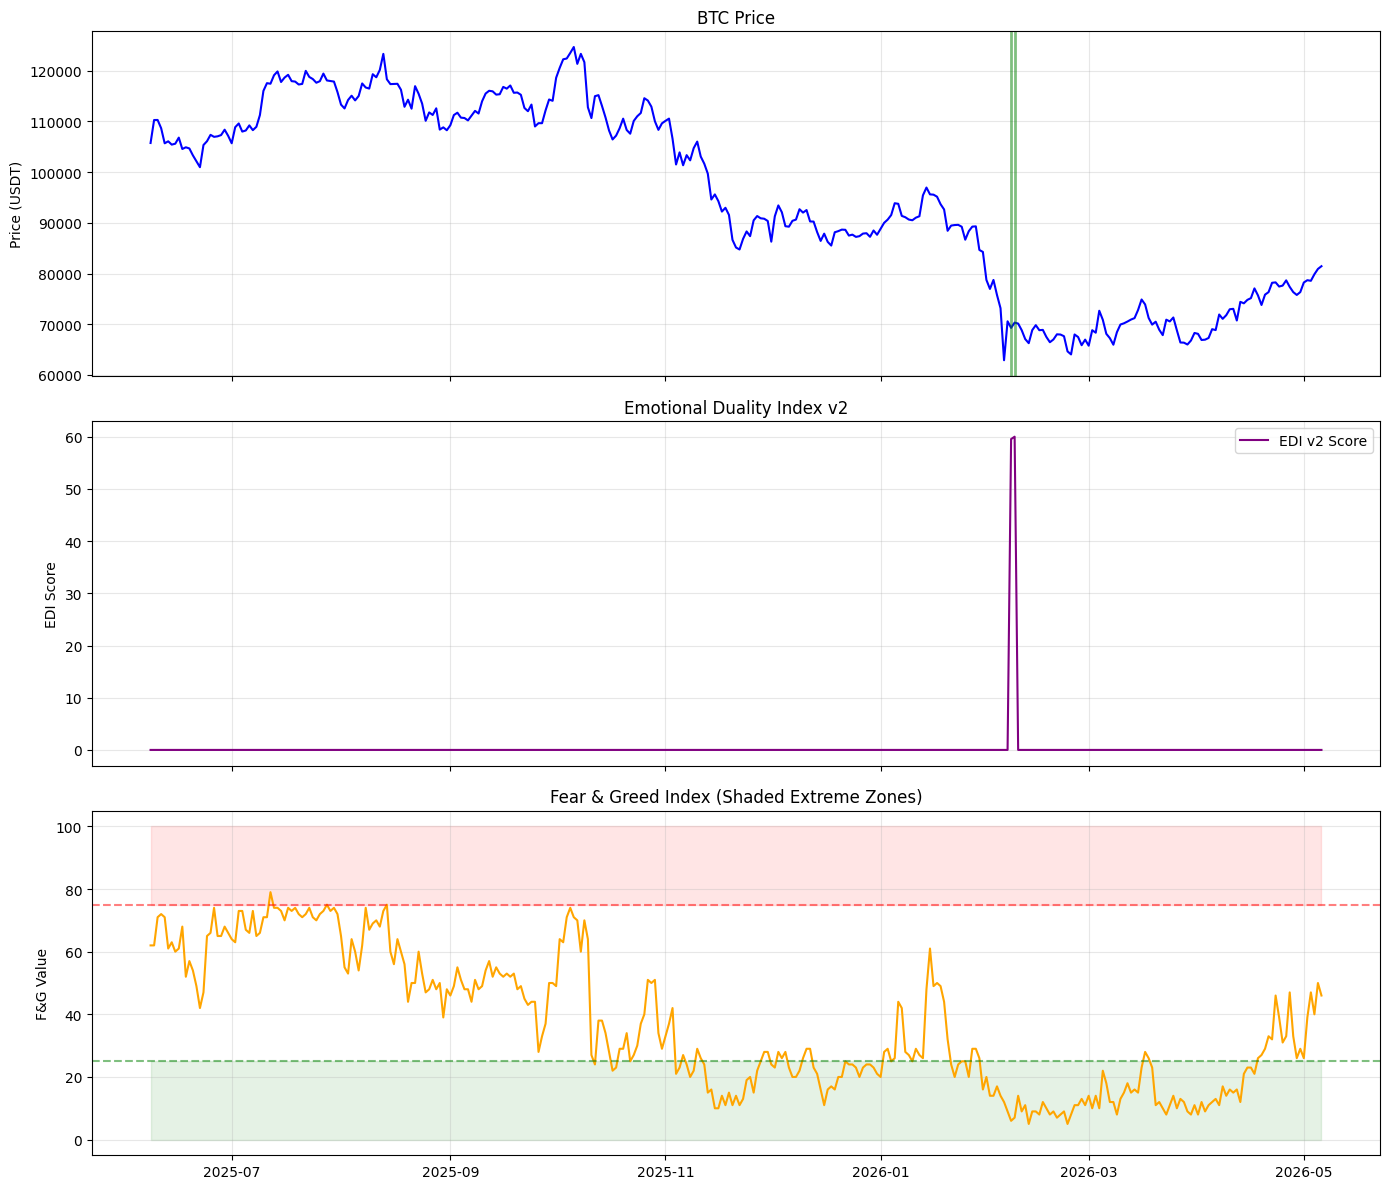

In [4]:
# Plotting BTC as primary example
df_btc = results["BTCUSDT"]

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(14, 12), sharex=True)

# Top panel: BTC Price
ax1.plot(df_btc.index, df_btc['close'], label='BTC Price', color='blue')
ax1.set_ylabel('Price (USDT)')
ax1.set_title('BTC Price')
ax1.grid(True, alpha=0.3)

# Highlight EDI v2 Fire Zones
fire_mask = df_btc['edi_score'] > 0
for idx in df_btc[fire_mask].index:
    ax1.axvline(x=idx, color='green' if df_btc.loc[idx, 'edi_direction'] == 'bullish_reversal' else 'red', alpha=0.5, linewidth=2)

# Middle panel: EDI Score
ax2.plot(df_btc.index, df_btc['edi_score'], label='EDI v2 Score', color='purple')
ax2.set_ylabel('EDI Score')
ax2.set_title('Emotional Duality Index v2')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Bottom panel: F&G
ax3.plot(df_btc.index, df_btc['fng_value'], label='Fear & Greed', color='orange')
ax3.axhline(y=75, color='red', linestyle='--', alpha=0.5)
ax3.fill_between(df_btc.index, 75, 100, color='red', alpha=0.1)
ax3.axhline(y=25, color='green', linestyle='--', alpha=0.5)
ax3.fill_between(df_btc.index, 0, 25, color='green', alpha=0.1)
ax3.set_ylabel('F&G Value')
ax3.set_title('Fear & Greed Index (Shaded Extreme Zones)')
ax3.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('edi_v2_btc_plot.png')
plt.show()

In [5]:
# Evaluation
total_fires = 0
correct_7d = 0
correct_14d = 0
total_7d_evaluable = 0
total_14d_evaluable = 0

returns_correct = []
returns_wrong = []

for asset, df in results.items():
    fires = df[df['edi_score'] > 0].copy()
    
    for idx, row in fires.iterrows():
        total_fires += 1
        dir = row['edi_direction']
        
        # 7d Evaluation
        if pd.notna(row['future_7d_return']):
            total_7d_evaluable += 1
            is_correct = (dir == 'bullish_reversal' and row['future_7d_return'] > 0) or                          (dir == 'bearish_reversal' and row['future_7d_return'] < 0)
            if is_correct:
                correct_7d += 1
                returns_correct.append(abs(row['future_7d_return']))
            else:
                returns_wrong.append(-abs(row['future_7d_return']))
                
        # 14d Evaluation
        if pd.notna(row['future_14d_return']):
            total_14d_evaluable += 1
            is_correct_14 = (dir == 'bullish_reversal' and row['future_14d_return'] > 0) or                             (dir == 'bearish_reversal' and row['future_14d_return'] < 0)
            if is_correct_14:
                correct_14d += 1

print(f"EDI v2 fired {total_fires} times in 365 days across {len(assets)} assets.")
if total_7d_evaluable > 0:
    hit_rate_7d = correct_7d / total_7d_evaluable * 100
    print(f"Of {total_7d_evaluable} evaluable fires, {correct_7d} correctly predicted direction within 7 days ({hit_rate_7d:.1f}% hit rate)")
if total_14d_evaluable > 0:
    hit_rate_14d = correct_14d / total_14d_evaluable * 100
    print(f"Of {total_14d_evaluable} evaluable fires, {correct_14d} correctly predicted direction within 14 days ({hit_rate_14d:.1f}% hit rate)")

if returns_correct:
    print(f"Average forward 7d return when fired correctly: +{np.mean(returns_correct)*100:.2f}%")
if returns_wrong:
    print(f"Average forward 7d return when fired wrong: {np.mean(returns_wrong)*100:.2f}%")


EDI v2 fired 5 times in 365 days across 3 assets.
Of 5 evaluable fires, 3 correctly predicted direction within 7 days (60.0% hit rate)
Of 5 evaluable fires, 2 correctly predicted direction within 14 days (40.0% hit rate)
Average forward 7d return when fired correctly: +2.39%
Average forward 7d return when fired wrong: -1.83%
